<a href="https://colab.research.google.com/github/SaanvikaVanga/FTI-DSRP-AI_Impact_Research/blob/main/Code_For_AI_Impact_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSRP AI Impact Research

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Data Cleaning + Initial Thoughts

In [ ]:
url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/AI%20and%20Digital%20Media/Global_AI_Content_Impact_Dataset.csv"

df = pd.read_csv(url)
df.head(10)

,Country,Year,Industry,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Top AI Tools Used,Regulation Status,Consumer Trust in AI (%),Market Share of AI Companies (%)
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
5,USA,2021,Retail,66.95,47.72,0.86,27.58,64.42,ChatGPT,Lenient,68.14,8.09
6,Australia,2023,Media,68.23,6.14,6.20,53.13,53.16,Claude,Moderate,71.60,15.26
7,UK,2023,Gaming,91.27,33.87,41.67,56.26,59.93,ChatGPT,Moderate,46.98,28.51
8,Canada,2025,Education,17.02,87.77,4.59,52.45,64.72,Claude,Moderate,60.55,22.70
9,China,2025,Healthcare,25.50,18.74,15.07,40.81,64.86,Stable Diffusion,Moderate,51.07,39.97


In [ ]:
df.info() # no nulls
print()
print("Duplicate rows:", df.duplicated().sum()) # no duplicates

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     200 non-null    object 
 1   Year                                        200 non-null    int64  
 2   Industry                                    200 non-null    object 
 3   AI Adoption Rate (%)                        200 non-null    float64
 4   AI-Generated Content Volume (TBs per year)  200 non-null    float64
 5   Job Loss Due to AI (%)                      200 non-null    float64
 6   Revenue Increase Due to AI (%)              200 non-null    float64
 7   Human-AI Collaboration Rate (%)             200 non-null    float64
 8   Top AI Tools Used                           200 non-null    object 
 9   Regulation Status                           200 non-null    object 
 10  Consumer Trust

In [ ]:
# seperation of numerical columns and categorical columns

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

num_df = df[num_cols]
cat_df = df[cat_cols]

In [ ]:
num_df.describe()

,Year,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Consumer Trust in AI (%),Market Share of AI Companies (%)
count,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2022.315000,54.265850,46.07260,25.788250,39.719450,54.102150,59.425150,26.569550
std,1.825496,24.218067,29.16122,13.901105,23.829545,19.247079,17.319668,14.023729
min,2020.000000,10.530000,1.04000,0.090000,0.140000,20.210000,30.120000,1.180000
25%,2021.000000,33.222500,20.32250,14.995000,17.907500,37.770000,44.755000,14.052500
50%,2022.000000,53.310000,44.32000,25.735000,42.100000,54.515000,59.215000,27.390000
75%,2024.000000,76.220000,71.62000,37.417500,58.697500,69.402500,74.885000,38.432500
max,2025.000000,94.760000,99.06000,49.710000,79.550000,88.290000,89.880000,49.280000


In [ ]:
cat_df.describe()

,Country,Industry,Top AI Tools Used,Regulation Status
count,200,200,200,200
unique,10,10,7,3
top,India,Media,Midjourney,Moderate
freq,24,31,37,76




> This dataset, while having data from a significant amount of countries around the world, may not be the most accurate representation of global AI impact on commercial countries. This dataset fails to include data on industries based in South America, Africa, Eastern Europe, Central America, Southeast Asia, Central Asia, and many other regions.





> This dataset only reaches until 2025, not potraying the recent trends of AI adoption



# Exploratory Data Analysis

Univariate Analysis

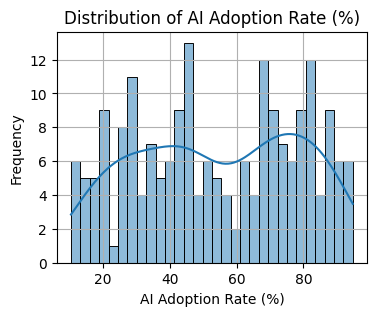

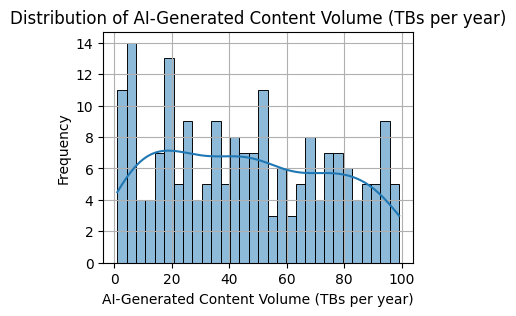

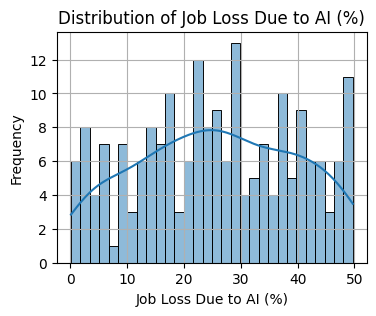

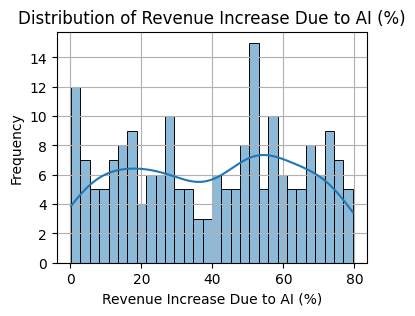

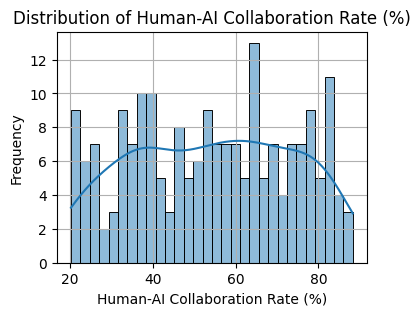

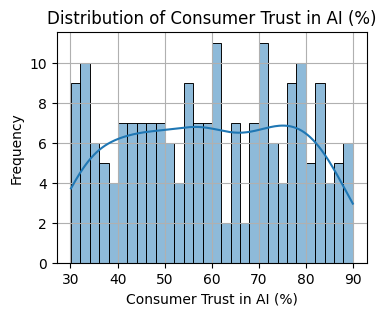

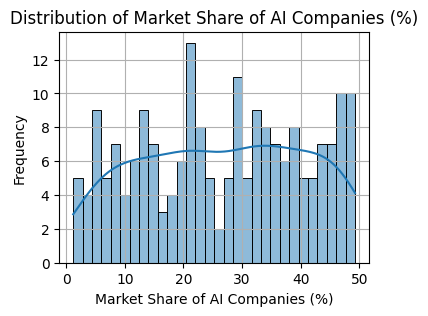

In [ ]:
for i in num_cols:
    if i == 'Year':
        continue
    plt.figure(figsize=(4, 3))
    sns.histplot(df[i], kde=True, bins=30)
    plt.grid(True)
    plt.xlabel(i)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {i}')
    plt.show()

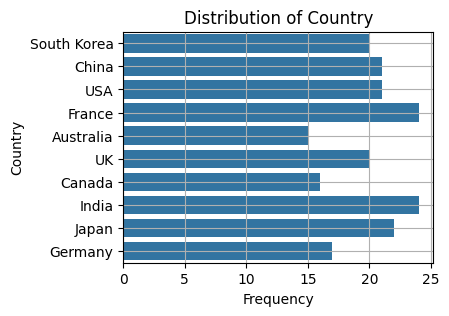

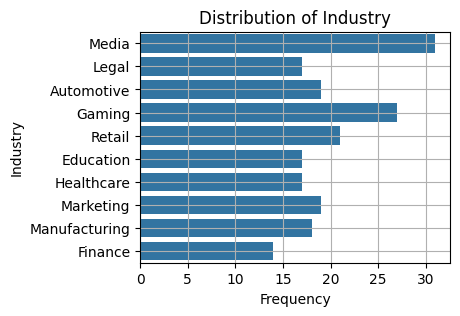

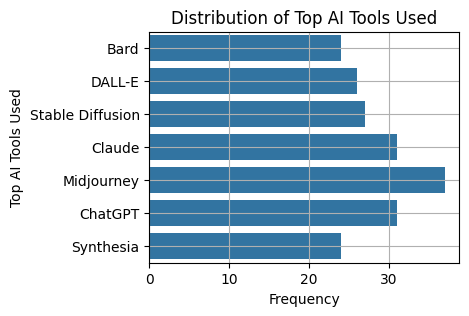

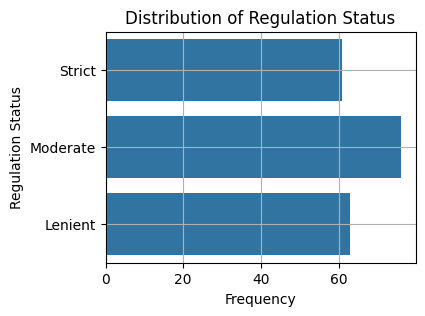

In [ ]:
for i in cat_cols:
    plt.figure(figsize=(4, 3))
    sns.countplot(data=df, y=i)
    plt.grid(True)
    plt.xlabel('Frequency')
    plt.ylabel(i)
    plt.title(f'Distribution of {i}')
    plt.show()

Bivariate Analysis

1. What types of industries have the highest AI adoption rates?

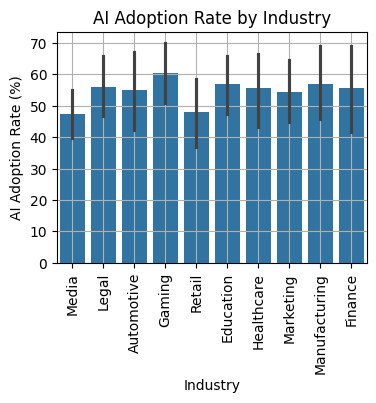

In [ ]:
plt.figure(figsize=(4, 3))
sns.barplot(data=df, x='Industry', y='AI Adoption Rate (%)')
plt.grid(True)
plt.xlabel('Industry')
plt.ylabel('AI Adoption Rate (%)')
plt.title('AI Adoption Rate by Industry')
plt.xticks(rotation=90)
plt.show()




> Gamimg industries have the highest AI adoption rates out of other industries



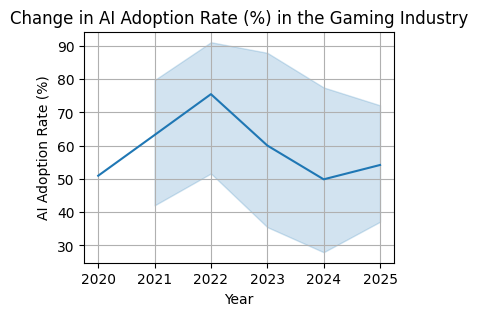

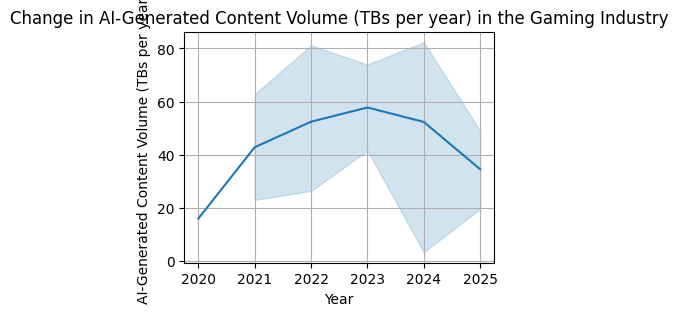

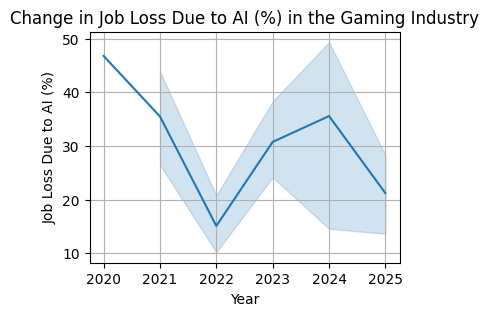

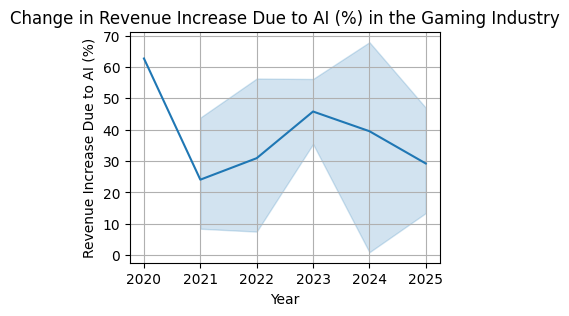

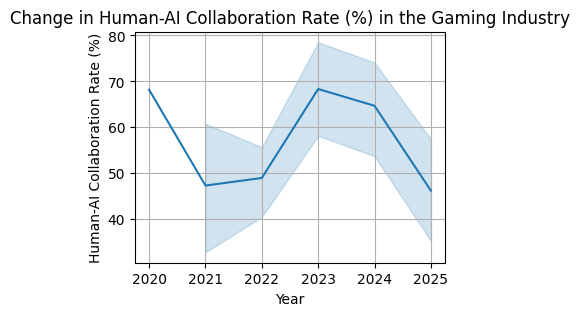

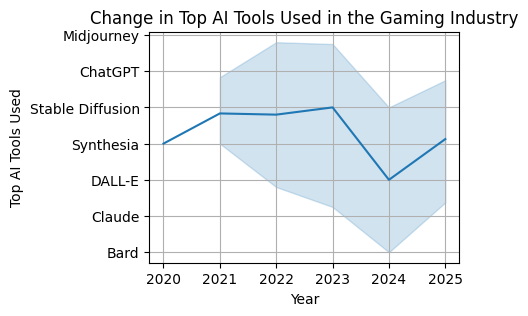

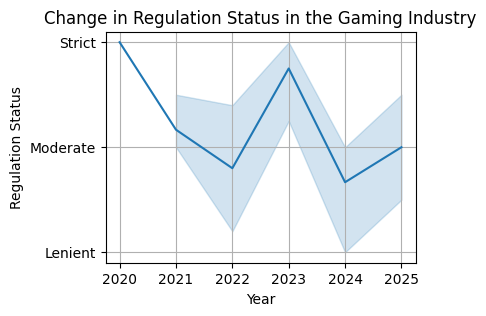

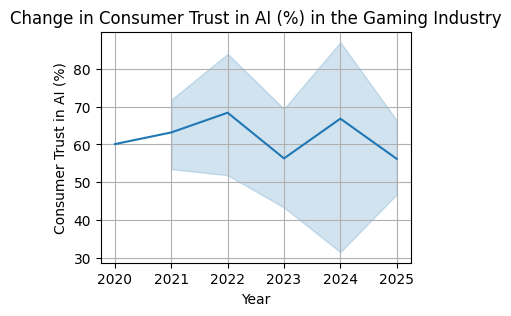

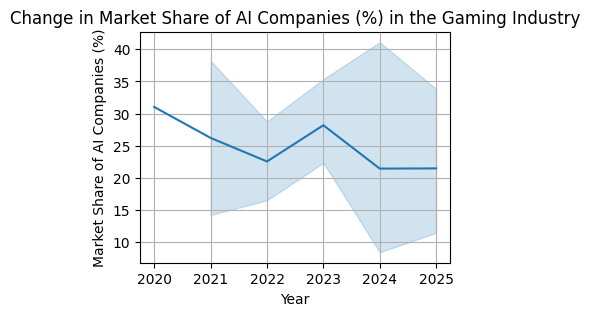

In [ ]:
gaming_df = df[df['Industry'] == 'Gaming']

tests = df.columns.tolist()
tests.remove('Industry')
tests.remove('Country')
tests.remove('Year')

for i in tests:
    plt.figure(figsize=(4, 3))
    sns.lineplot(data=gaming_df, x='Year', y=i)
    plt.title(f'Change in {i} in the Gaming Industry')
    plt.grid(True)
    plt.xlabel('Year')



> Human-AI collaboration rates and Revenue Increase line plots mimmic each other



2. What AI tools are most utillized in the gaming industry?

['Media' 'Legal' 'Automotive' 'Gaming' 'Retail' 'Education' 'Healthcare'
 'Marketing' 'Manufacturing' 'Finance']


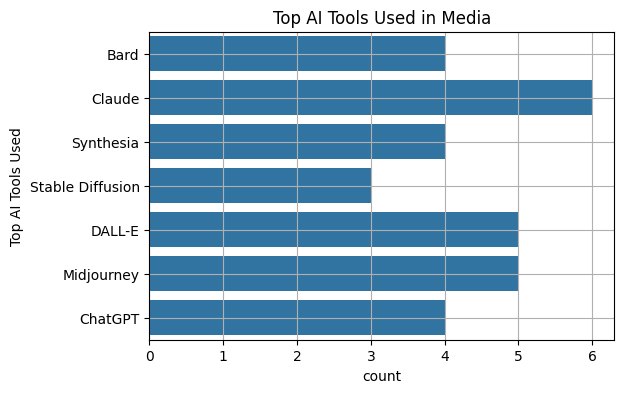

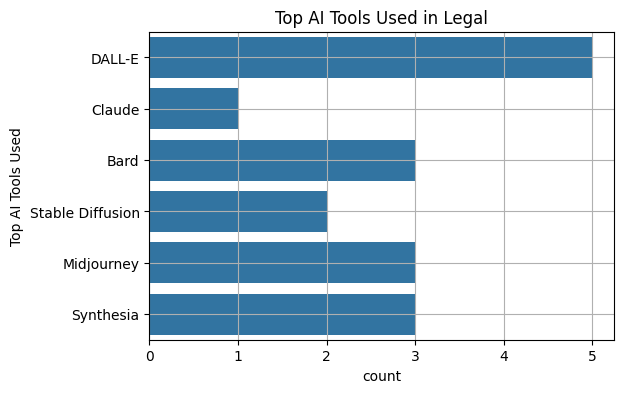

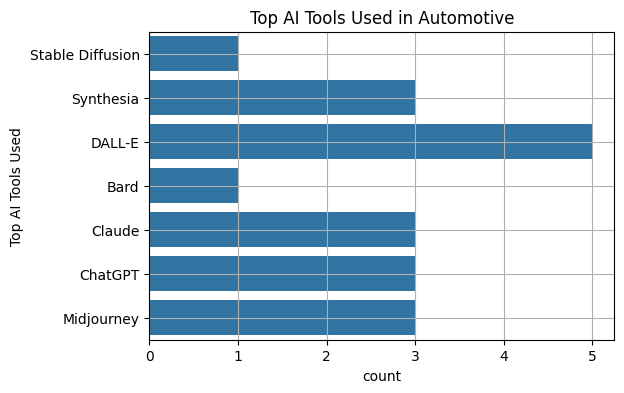

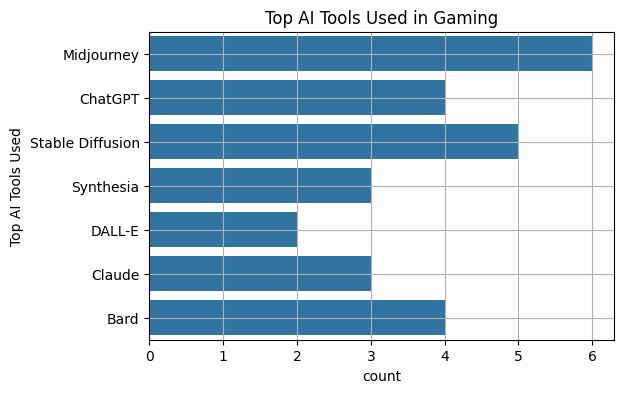

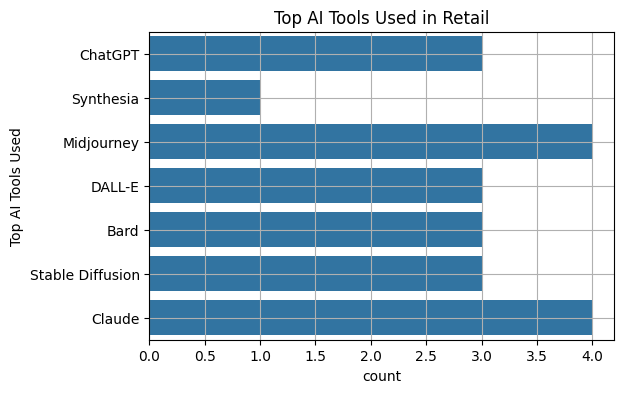

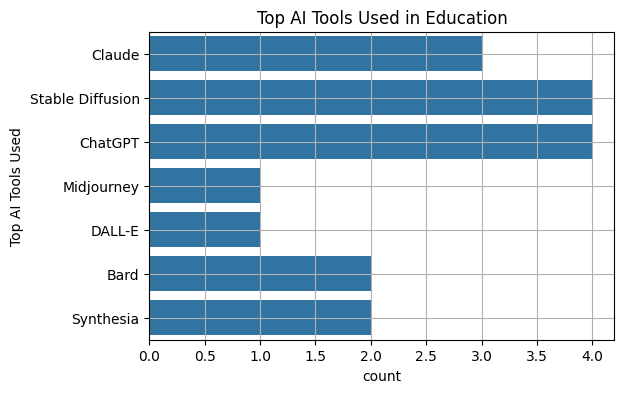

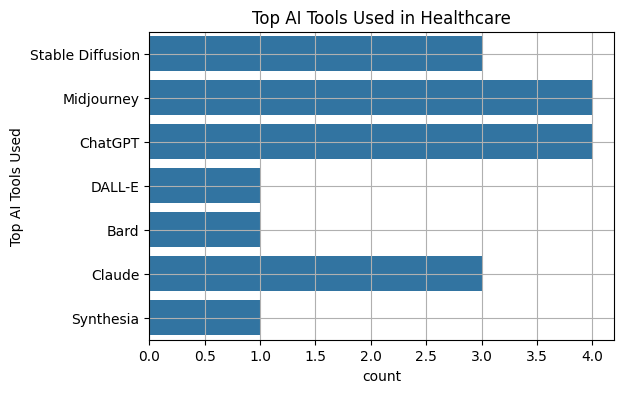

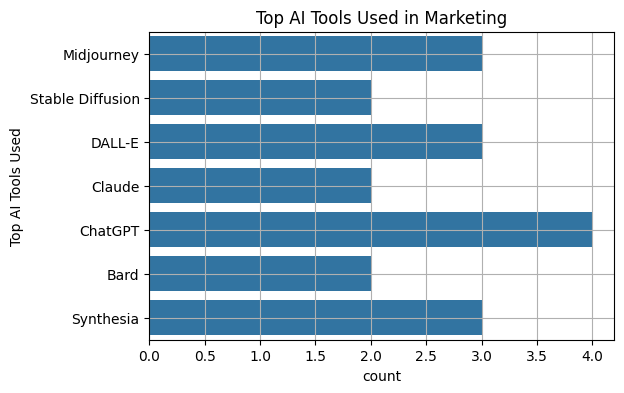

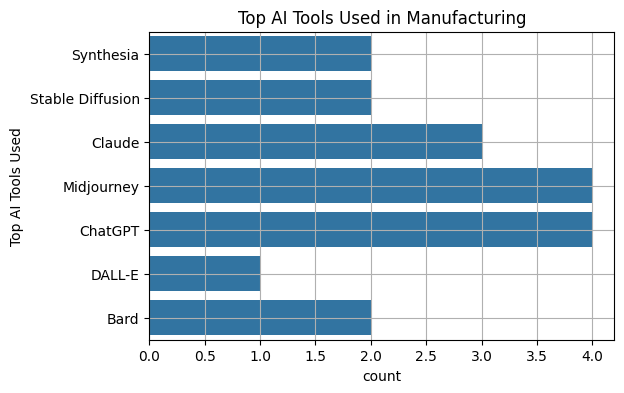

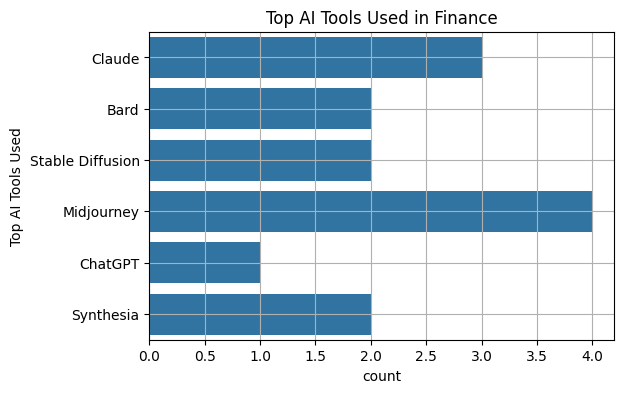

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=gaming_df, y='Top AI Tools Used')
plt.grid(True)
plt.ylabel('Top AI Tools Used')
plt.title(f'Top AI Tools Used in {i}')
plt.show()

2. What AI models contribute to greater...
   *  revenue increase?
   *  human-AI collaboration rates?
   *  AI-generated content volume?
   *  job loss?
   *  AI adoption rates?
   *  customer trust in AI?

['Bard' 'DALL-E' 'Stable Diffusion' 'Claude' 'Midjourney' 'ChatGPT'
 'Synthesia']


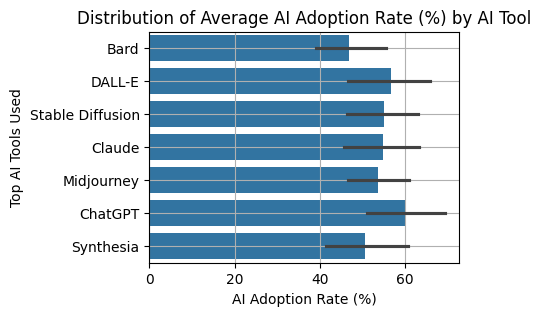

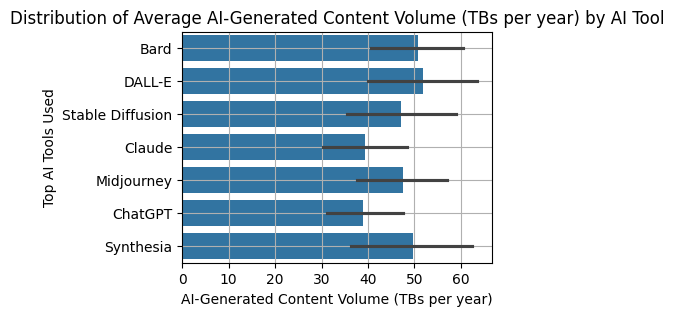

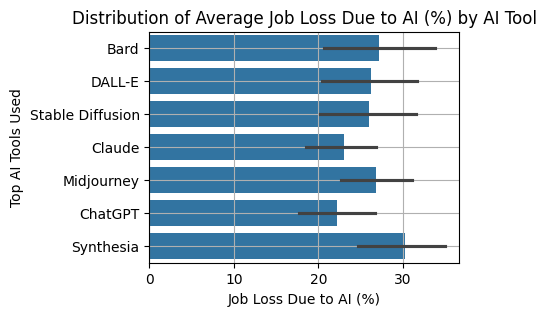

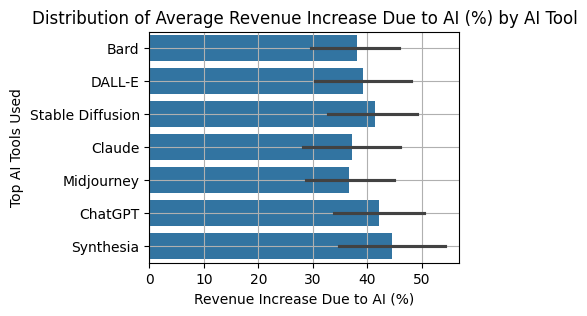

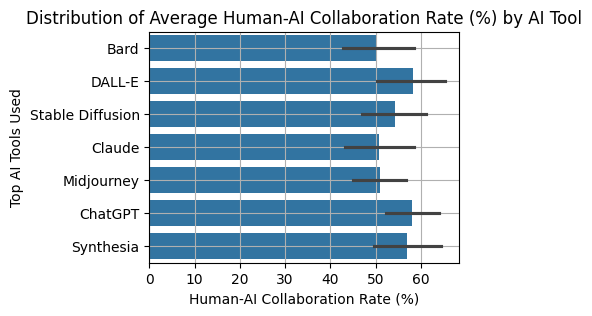

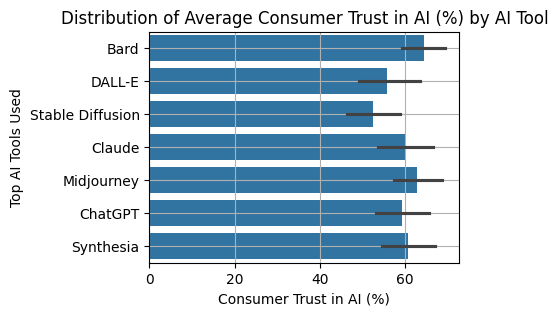

In [ ]:
tools = df['Top AI Tools Used'].unique()
print(tools)

tests = [ 'AI Adoption Rate (%)',
 'AI-Generated Content Volume (TBs per year)',
 'Job Loss Due to AI (%)',
 'Revenue Increase Due to AI (%)',
 'Human-AI Collaboration Rate (%)',
 'Consumer Trust in AI (%)',]

for t in tests:
    plt.figure(figsize=(4, 3))
    sns.barplot(data=df, y='Top AI Tools Used', x=t)
    plt.grid(True)
    plt.xlabel(t)
    plt.ylabel('Top AI Tools Used')
    plt.title(f'Distribution of Average {t} by AI Tool')
    plt.show()

In [ ]:
df["Top AI Tools Used"].value_counts()

,count
Top AI Tools Used,
Midjourney,37
Claude,31
ChatGPT,31
Stable Diffusion,27
DALL-E,26
Bard,24
Synthesia,24


Changes over Time

['AI Adoption Rate (%)', 'AI-Generated Content Volume (TBs per year)', 'Job Loss Due to AI (%)', 'Revenue Increase Due to AI (%)', 'Human-AI Collaboration Rate (%)', 'Consumer Trust in AI (%)', 'Market Share of AI Companies (%)']


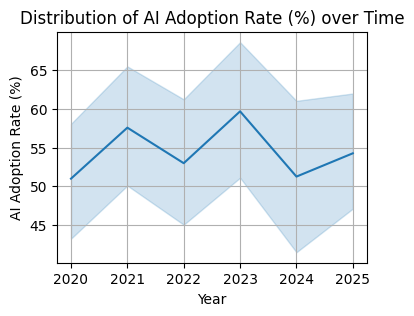

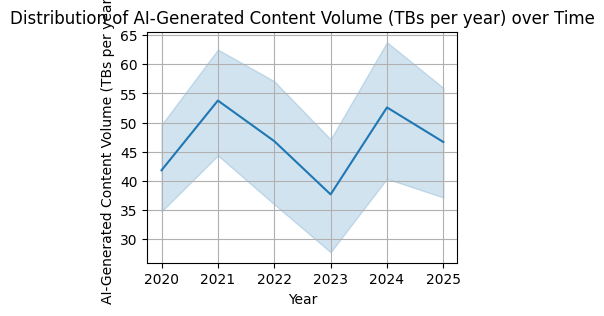

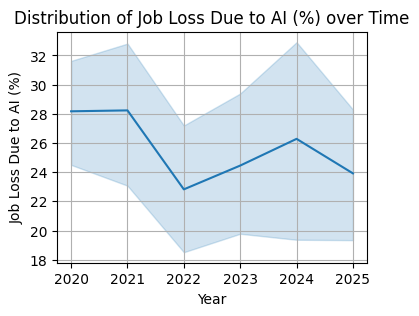

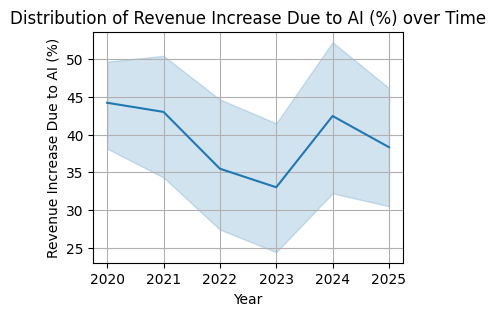

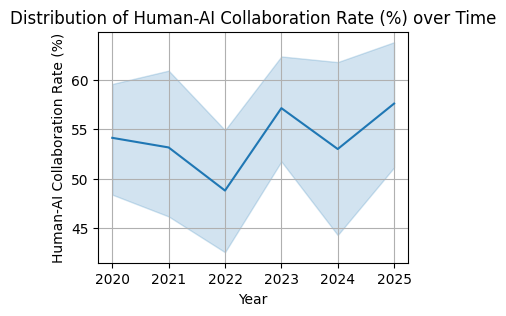

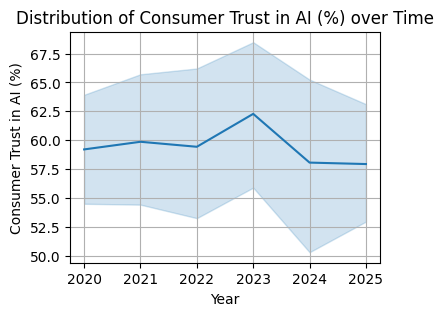

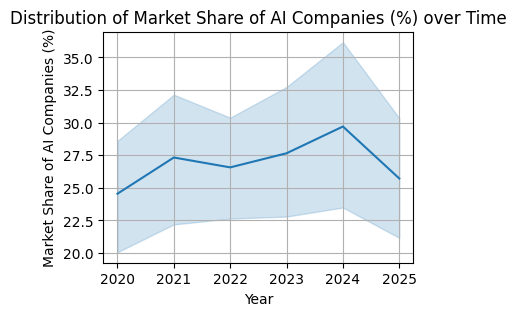

In [ ]:
cols = [col for col in num_cols if col != 'Year']
print(cols)

for i in cols:
    plt.figure(figsize=(4, 3))
    sns.lineplot(data=df, x='Year', y=i)
    plt.grid(True)
    plt.xlabel('Year')
    plt.ylabel(i)
    plt.title(f'Distribution of {i} over Time')
    plt.show()